In [90]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import plotly.express as px

session_df = pd.read_csv("../data/analysis_table/session_table.csv")
user_df = pd.read_csv("../data/analysis_table/user_table.csv")
funnel = pd.read_csv("../data/analysis_table/funnel_table.csv")

In [91]:
# 1. Conversion Rate
view_sessions = funnel.loc[funnel['stage'] == 'view', 'sessions'].iloc[0]
funnel['conversion_rate'] = funnel['sessions'] / view_sessions

print(funnel)

   Unnamed: 0     stage  sessions  conversion_rate
0           0      view   2781434         1.000000
1           1      cart    348312         0.125227
2           2  purchase    153412         0.055156


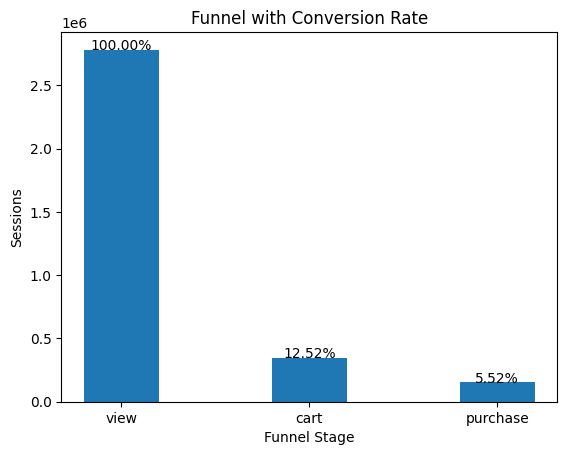

In [92]:
# Visualization: Funnel with Conversion Rate
plt.figure()
bars = plt.bar(funnel['stage'], funnel['sessions'], width = 0.4)

for index, row in funnel.iterrows():
    plt.text(x = row['stage'], y = row['sessions'], s = f"{row['conversion_rate']:.2%}", ha = 'center')

plt.title('Funnel with Conversion Rate')
plt.xlabel('Funnel Stage')
plt.ylabel('Sessions')

plt.show()

In [93]:
# 2. Drop-off Rate
# calculate conversion rate of each steps
funnel['step_conversion_rate'] = (funnel['sessions'] / funnel['sessions'].shift(1))

# set the first step(NaN) to 1
funnel.loc[0, 'step_conversion_rate'] = 1 

# calculate drop-off rate
funnel['drop_off_rate'] = 1 - funnel['step_conversion_rate']

print(funnel)

   Unnamed: 0     stage  sessions  conversion_rate  step_conversion_rate  \
0           0      view   2781434         1.000000              1.000000   
1           1      cart    348312         0.125227              0.125227   
2           2  purchase    153412         0.055156              0.440444   

   drop_off_rate  
0       0.000000  
1       0.874773  
2       0.559556  


In [94]:
# Visualization: Drop-off rate
stages = funnel['stage']
values = funnel['sessions']
max_value = values.iloc[0]   # default view being the max value
left = (max_value - values) / 2

fig = px.funnel(funnel, x = "sessions", y = "stage")

fig.update_layout(title = "Conversion Funnel")

fig.show()

'''
plt.figure(figsize = (6, 4))

plt.barh(y = stages, width = values, left = left)

for i, v in enumerate(values):
    plt.text(max_value/2, i, f"{v:,}", 
             ha='center', va='center')

plt.title("Conversion Funnel")
plt.xlabel("Number of Sessions")
plt.gca().invert_yaxis()   # put view to the top

plt.show()
'''

'\nplt.figure(figsize = (6, 4))\n\nplt.barh(y = stages, width = values, left = left)\n\nfor i, v in enumerate(values):\n    plt.text(max_value/2, i, f"{v:,}", \n             ha=\'center\', va=\'center\')\n\nplt.title("Conversion Funnel")\nplt.xlabel("Number of Sessions")\nplt.gca().invert_yaxis()   # put view to the top\n\nplt.show()\n'

In [95]:
# 3. Time to Convert: how much time does viewing to purchasing takes
oct_2019 = pd.read_csv("../data/analysis_table/data_cleaned.csv")

view_times = (
    oct_2019[oct_2019['event_type'] == 'view'].groupby(['user_id', 'user_session'])['event_time']
    .min()   # take the min as first view time
    .reset_index()
    .rename(columns = {'event_time' : "first_view_time"})
)

view_times.head()

,user_id,user_session,first_view_time
0,43295513,9f49a167-1cb1-4918-8d47-1ccb1c4b4f39,2019-11-26 11:17:14+00:00
1,49484535,0748511a-6ddf-4018-b093-8779cf863e4e,2019-11-22 15:30:22+00:00
2,49484535,08d4b672-8592-4569-9bcf-94449ab2e471,2019-11-22 15:43:04+00:00
3,49484535,0b564e29-57a2-48c2-bc93-7b35b96b7a84,2019-11-27 13:09:11+00:00
4,49484535,16d460d5-d37e-4a4d-bb9c-3e9bb862dfe7,2019-11-20 17:08:37+00:00


In [96]:
purchase_times = (
    oct_2019[oct_2019['event_type'] == 'purchase'].groupby(['user_id', 'user_session'])['event_time']
    .min()   # take the min as first view time
    .reset_index()
    .rename(columns = {'event_time' : "first_purchase_time"})
)

time_to_convert = pd.merge(
    view_times, purchase_times, on = ['user_id', 'user_session'], how = 'inner'  # only considering sessions which had purchase
)

time_to_convert.head()

,user_id,user_session,first_view_time,first_purchase_time
0,256164170,56bbfca9-4dab-4d43-adf7-a47ea1ae8000,2019-11-20 08:10:54+00:00,2019-11-20 08:21:14+00:00
1,296197073,068753bd-2ccb-4332-b15c-cdd77f83ce65,2019-11-30 08:39:07+00:00,2019-11-30 08:50:49+00:00
2,296197073,5cb3db39-4780-4418-9a38-0b0880f788a8,2019-11-30 11:10:53+00:00,2019-11-30 11:12:52+00:00
3,307574312,0df1492a-f62a-4856-8a92-a6fd21dffd58,2019-11-20 06:16:26+00:00,2019-11-20 06:22:04+00:00
4,308228668,95bd09f5-40ca-4f1f-b572-67492489dab8,2019-11-19 11:34:24+00:00,2019-11-19 11:43:58+00:00


In [97]:
time_to_convert.dtypes
# after the merge, time format became object again, so we need to convert to datetime again

user_id                 int64
user_session           object
first_view_time        object
first_purchase_time    object
dtype: object

In [98]:
# convert to datetime again
time_to_convert['first_view_time'] = pd.to_datetime(time_to_convert['first_view_time'], utc = True)

time_to_convert['first_purchase_time'] = pd.to_datetime(time_to_convert['first_purchase_time'], utc = True)

# calculate the time to convert in minutes
time_to_convert['time_to_purchase_min'] = (time_to_convert['first_purchase_time'] - time_to_convert['first_view_time']).dt.total_seconds()/60

time_to_convert['time_to_purchase_min'] = time_to_convert['time_to_purchase_min'].round(2)

time_to_convert.head()

,user_id,user_session,first_view_time,first_purchase_time,time_to_purchase_min
0,256164170,56bbfca9-4dab-4d43-adf7-a47ea1ae8000,2019-11-20 08:10:54+00:00,2019-11-20 08:21:14+00:00,10.33
1,296197073,068753bd-2ccb-4332-b15c-cdd77f83ce65,2019-11-30 08:39:07+00:00,2019-11-30 08:50:49+00:00,11.70
2,296197073,5cb3db39-4780-4418-9a38-0b0880f788a8,2019-11-30 11:10:53+00:00,2019-11-30 11:12:52+00:00,1.98
3,307574312,0df1492a-f62a-4856-8a92-a6fd21dffd58,2019-11-20 06:16:26+00:00,2019-11-20 06:22:04+00:00,5.63
4,308228668,95bd09f5-40ca-4f1f-b572-67492489dab8,2019-11-19 11:34:24+00:00,2019-11-19 11:43:58+00:00,9.57


In [ ]:
# 4. Behavioral Difference and Uplift Ratio between converters (those who purchased) v.s. non-converters (not purchased)

# identify if the session converts or not
session_df['is_converter'] = (session_df['has_purchase'] == 1)

# session_duration_sec already computed in 01_data_prep and saved in session_table.csv
session_df['session_duration_min'] = (session_df['session_duration_sec'] / 60).round(2)

# define behavior metrics
behavior_metrics = ['session_duration_min', 'total_events', 'view_count', 'cart_count']

session_df.head()

In [100]:
# calculate average of converters v.s. non-converter
behavior_summary = (session_df.groupby('is_converter')[behavior_metrics].mean().round(2))

behavior_summary = behavior_summary.T
behavior_summary.columns = ['non_converter','converter']

print(behavior_summary)

                      non_converter  converter
session_duration_min          15.55      10.56
total_events                   4.64       8.67
view_count                     4.50       6.02
cart_count                     0.14       1.47


In [101]:
# calculate Uplift Ratio to better understand the relative difference between converters v.s. non-converters
behavior_summary['uplift_ratio'] = (behavior_summary['converter'] / behavior_summary['non_converter']).round(2)

print(behavior_summary)

                      non_converter  converter  uplift_ratio
session_duration_min          15.55      10.56          0.68
total_events                   4.64       8.67          1.87
view_count                     4.50       6.02          1.34
cart_count                     0.14       1.47         10.50


## Funnel Analysis Summary

This notebook contains four main parts as below which evaluate the end-to-end purchase funnel and compares behavioral differences between converting and non-converting sessions.

### 1. Funnel Performance Overview

**View → Cart → Purchase**

Key metrics:
- Overall conversion rate from view to purchase
- Step-by-step conversion and drop-off rates between stages

12.5% of sessions add viewed products to cart, and once a product is added to the cart, 44% of those sessions result in a purchase.

### 2. Time to Convert

The time between a user's first product view and their first purchase within the same session.

- How quickly users make purchase decisions

### 3. Behavioral Differences: Converters vs Non-Converters

Session behavior comparison between sessions that resulted in purchase and those that did not.

Key behavior metrics:
- Session duration
- Number of total events in the session
- View counts in the session
- Cart counts in the session

Converting sessions show higher engagement, generating 87% more events 34% more views, but spend 32% less time. Buyers are more efficient and decisive while longer sessions aften reflect simply browsing rather than actual purchase intent.
